In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os,glob
import datetime
import gsw
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
#import cmocean
import cartopy
#cartopy.config['pre_existing_data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
#cartopy.config['data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
#cartopy.config['repo_data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
ix = pd.read_csv('/espace/home/ref-argo/gdac/ar_index_global_prof.txt', 
                 sep=',', index_col=None, header=0, skiprows=8,
                 names=['file','date','latitude','longitude','ocean','profiler_type','institution','update'], 
                 dtype={'file': np.str_, 'latitude': np.float32, 'longitude': np.float32, 'ocean': str, 'profiler_type': str, 'institution': str}
                )
ix.tail()

,file,date,latitude,longitude,ocean,profiler_type,institution,update
3240309,nmdis/2901633/profiles/R2901633_067.nc,2.013050e+13,27.462000,139.106995,P,841,NM,20130507103443
3240310,nmdis/2901633/profiles/R2901633_068.nc,2.013051e+13,27.431999,138.839996,P,841,NM,20130511165723
3240311,nmdis/2901633/profiles/R2901633_069.nc,2.013052e+13,27.691999,138.677002,P,841,NM,20130521170139
3240312,nmdis/2901633/profiles/R2901633_070.nc,2.013053e+13,27.895000,138.464996,P,841,NM,20130531181516
3240313,nmdis/2901633/profiles/R2901633_071.nc,2.013061e+13,27.931000,138.089996,P,841,NM,20130617181801


In [4]:
ixs = ix[(ix['profiler_type']=='838')]

ixs = ixs.reset_index().drop(columns='index')
# parse the date after the subset, much more fast than inside the pd.read_csv()
ixs['date']= pd.to_datetime(ixs['date'],format='%Y%m%d%H%M%S')
# period of interest [datemin, datemax]
poi = np.array(['2023-12-01','2025-10-31'],dtype='datetime64')
ixs = ixs[(ixs['date']>=poi[0])&(ixs['date']<=poi[1])].reset_index()

# dac generation
dacs = {'AO':'aoml','BO':'bodc','IF':'coriolis','HZ':'csio','CS':'csiro','IN':'incois','JA':'jma','KM':'kma','KO':'kordi','ME':'meds','NM':'nmdis'}
ixs['wmo']=[int(f.split('/')[1]) for f in ixs['file']]
ixs['dac']=[dacs[f] for f in ixs['institution']]
ixs = ixs.groupby('wmo').last().reset_index()
ixs.tail()

,wmo,index,file,date,latitude,longitude,ocean,profiler_type,institution,update,dac
100,7901036,12173,coriolis/7901036/profiles/R7901036_085.nc,2025-10-23 07:10:00,39.403000,-45.025002,A,838,IF,20251023083203,coriolis
101,7901037,12199,coriolis/7901037/profiles/D7901037_024.nc,2024-02-19 18:01:00,60.165001,-49.634998,A,838,IF,20250321153041,coriolis
102,7902215,12232,coriolis/7902215/profiles/R7902215_032.nc,2025-05-22 00:17:00,42.999001,-56.331001,A,838,IF,20250522012631,coriolis
103,7902309,12237,coriolis/7902309/profiles/R7902309_004.nc,2025-10-24 22:55:00,43.081001,-53.609001,A,838,IF,20251025002822,coriolis
104,7902326,12250,coriolis/7902326/profiles/R7902326_011.nc,2025-10-23 16:40:00,40.960999,7.765000,A,838,IF,20251023172830,coriolis


In [6]:
ixs.query('dac=="meds"')

,wmo,index,file,date,latitude,longitude,ocean,profiler_type,institution,update,dac
22,4902631,13033,meds/4902631/profiles/R4902631_055.nc,2025-10-29 13:33:00,50.187000,-141.203995,P,838,ME,20251029121516,meds
23,4902633,13125,meds/4902633/profiles/R4902633_091.nc,2025-10-25 14:28:00,52.000999,-148.901993,P,838,ME,20251107133545,meds
24,4902634,13217,meds/4902634/profiles/R4902634_091.nc,2025-10-23 14:41:00,48.529999,-136.848999,P,838,ME,20251104164938,meds
25,4902635,13303,meds/4902635/profiles/R4902635_085.nc,2025-10-28 01:55:00,56.030998,-141.654999,P,838,ME,20251106153423,meds
26,4902636,13389,meds/4902636/profiles/R4902636_085.nc,2025-10-29 13:18:00,57.431999,-149.968994,P,838,ME,20251106153527,meds
27,4902637,13475,meds/4902637/profiles/R4902637_085.nc,2025-10-30 13:02:00,55.712002,-150.792007,P,838,ME,20251106153632,meds
28,4902638,13539,meds/4902638/profiles/R4902638_064.nc,2025-10-26 04:37:00,-52.005001,-39.819000,A,838,ME,20251106163848,meds
29,4902639,13598,meds/4902639/profiles/R4902639_059.nc,2025-09-06 11:23:00,-57.528000,-22.653999,A,838,ME,20251106163929,meds
30,4902640,13638,meds/4902640/profiles/R4902640_042.nc,2025-10-24 13:32:00,48.918999,-151.787003,P,838,ME,20251024121514,meds
31,4902641,13677,meds/4902641/profiles/R4902641_042.nc,2025-10-23 13:26:00,48.398998,-145.376999,P,838,ME,20251023121513,meds


In [34]:
dc = xr.open_dataset('/espace/home/ref-argo/gdac/dac/coriolis/6902972/6902972_meta.nc')

In [37]:
dc['LAUNCH_CONFIG_PARAMETER_NAME'].values

array([b'CONFIG_DelayBeforeMissionStart_minutes                                                                                          ',
       b'CONFIG_MaxCycles_NUMBER                                                                                                         ',
       b'CONFIG_CycleTime_days                                                                                                           ',
       b'CONFIG_FloatReferenceDay_FloatDay                                                                                               ',
       b'CONFIG_SurfaceTime_HH                                                                                                           ',
       b'CONFIG_DescentToParkPresSamplingTime_seconds                                                                                    ',
       b'CONFIG_ParkSamplingPeriod_hours                                                                                                 ',
       b'CONFIG_Asce

In [38]:
dt = xr.open_dataset('/espace/home/ref-argo/gdac/dac/coriolis/6902972/6902972_Rtraj.nc')

/tmp/ipykernel_80177/1358972385.py:1: FutureWarning: In a future version, xarray will not decode the variable 'CLOCK_OFFSET' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dt = xr.open_dataset('/espace/home/ref-argo/gdac/dac/coriolis/6902972/6902972_Rtraj.nc')


In [39]:
np.unique(dt['MEASUREMENT_CODE'])

array([  0.,  89., 100., 150., 189., 190., 198., 203., 250., 289., 290.,
       297., 298., 300., 301., 389., 398., 450., 489., 497., 498., 500.,
       503., 589., 590., 599., 600., 700., 702., 703., 704., 710., 711.,
       800., 901.])

In [27]:
dc = xr.open_dataset('/espace/home/ref-argo/gdac/dac/csio/2902738/2902738_meta.nc')
dc

<xarray.Dataset> Size: 976B
Dimensions:                               (N_TRANS_SYSTEM: 1,
                                           N_POSITIONING_SYSTEM: 2,
                                           N_LAUNCH_CONFIG_PARAM: 9,
                                           N_CONFIG_PARAM: 9, N_MISSIONS: 1,
                                           N_SENSOR: 3, N_PARAM: 3)
Dimensions without coordinates: N_TRANS_SYSTEM, N_POSITIONING_SYSTEM,
                                N_LAUNCH_CONFIG_PARAM, N_CONFIG_PARAM,
                                N_MISSIONS, N_SENSOR, N_PARAM
Data variables: (12/65)
    DATA_TYPE                             object 8B ...
    FORMAT_VERSION                        object 8B ...
    HANDBOOK_VERSION                      object 8B ...
    DATE_CREATION                         object 8B ...
    DATE_UPDATE                           object 8B ...
    PLATFORM_NUMBER                       object 8B ...
    ...                                    ...
    PARAMETER_UNITS                       (N_PARAM) object 24B ...
    PARAMETER_ACCURACY                    (N_PARAM) object 24B ...
    PARAMETER_RESOLUTION                  (N_PARAM) object 24B ...
    PREDEPLOYMENT_CALIB_EQUATION          (N_PARAM) object 24B ...
    PREDEPLOYMENT_CALIB_COEFFICIENT       (N_PARAM) object 24B ...
    PREDEPLOYMENT_CALIB_COMMENT           (N_PARAM) object 24B ...
Attributes:
    title:                Argo float metadata file
    institution:          CSIO
    source:               Argo float
    history:              2018-01-18T01:23:12Z creation
    references:           http://www.argodatamgt.org/Documentation
    comment:              free text
    user_manual_version:  3.10
    Conventions:          Argo-3.1 CF-1.6
    featureType:          meta

In [4]:
grnd=np.zeros(0,dtype=np.float64)      # bathymetry estimate a.k.a grounding from the Deep Arvor floats
jae_grnd=np.zeros(0,dtype=np.float64)  # julian day of ascent end time for surface interval after Deep Arvor grounding
jday_gps=np.zeros(0,dtype=np.float64)  # julian day of first gps location after Deep Arvor grounding
jds_grnd=np.zeros(0,dtype=np.float64)  # julian day of descent start time for surface interval after Deep Arvor grounding
jday_grnd=np.zeros(0,dtype=np.float64) # julian day of Deep Arvor grounding
lat_gps=np.zeros(0,dtype=np.float64)   # latitude of first gps location after Deep Arvor grounding*
lon_gps=np.zeros(0,dtype=np.float64)   # longitude of first gps location after Deep Arvor grounding*
dir_grnd=np.zeros(0,dtype=int)+2       #flag for profile direction : 2 for ascending_cy
wmol = np.zeros(0,dtype=int)
cyc = np.zeros(0,dtype=int)

In [5]:
for i in range(len(ixs)):    
    #gen path
    urlt="/home/ref-argo/gdac/dac/"+ixs['dac'][i]+"/"+str(ixs['wmo'][i])+"/"+str(ixs['wmo'][i])+"_Rtraj.nc"       
    #check for traj file
    if (os.path.exists(urlt)):
        try:            
            dt = xr.open_dataset(urlt)        
            # Check if there's any grounding with the GROUNDED variable
            cycles_grounded = np.argwhere(np.isin(dt['GROUNDED'].values.astype(str),['Y'])).T[0]
            grounded = dt['CYCLE_NUMBER_INDEX'].values[cycles_grounded]                          
        except:            
            pass
        # IF there's any ...
        if (len(cycles_grounded)>0):                                    
            for cycle in grounded:
                try:
                    dt0 = dt[['CYCLE_NUMBER','JULD','PRES','LATITUDE','LONGITUDE','MEASUREMENT_CODE']].where(dt['CYCLE_NUMBER']==cycle,drop=True)
                    #check if grounded during descent to profile                
                    park_end = dt0[['CYCLE_NUMBER','JULD']].where(dt0['MEASUREMENT_CODE']==300.,drop=True)                               
                    grounding = dt0.where(dt0['MEASUREMENT_CODE']==901,drop=True).groupby('CYCLE_NUMBER').last() 
                    if grounding['JULD'] < park_end['JULD'] :
                        continue
                    else:
                        ascent_end = dt0.where(dt0['MEASUREMENT_CODE']==590,drop=True).groupby('CYCLE_NUMBER').last()
                        first_fix = dt0.where(dt0['MEASUREMENT_CODE']==703,drop=True).groupby('CYCLE_NUMBER').first()      
                        descent_start = dt0.where(dt0['MEASUREMENT_CODE']==704,drop=True)                                 
                        #assign
                        ref=np.datetime64('1950-01-01T00:00:00')
                        grnd      = np.append(grnd,
                                              -1*gsw.z_from_p(grounding['PRES'].values,first_fix['LATITUDE'].values)[0])
                        jae_grnd  = np.append(jae_grnd,
                                              np.timedelta64(ascent_end['JULD'].values[0]-ref,'s').astype(float)/(3600*24) if ~np.isnat(ascent_end['JULD'].values[0]) else np.nan)
                        jday_gps  = np.append(jday_gps,
                                              np.timedelta64(first_fix['JULD'].values[0]-ref,'s').astype(float)/(3600*24) if ~np.isnat(first_fix['JULD'].values[0]) else np.nan)
                        jds_grnd  = np.append(jds_grnd,
                                              np.timedelta64(descent_start['JULD'].values[0]-ref,'s').astype(float)/(3600*24) if ~np.isnat(descent_start['JULD'].values[0]) else np.nan)
                        jday_grnd = np.append(jday_grnd,
                                              np.timedelta64(grounding['JULD'].values[0]-ref,'s').astype(float)/(3600*24) if ~np.isnat(grounding['JULD'].values[0]) else np.nan)
                        lat_gps = np.append(lat_gps,first_fix['LATITUDE'].values[0])
                        lon_gps = np.append(lon_gps,first_fix['LONGITUDE'].values[0])
                        wmol = np.append(wmol,int(ixs['wmo'][i]))
                        cyc = np.append(cyc,int(cycle))           
                except :
                    pass

In [6]:
#remove any weird points
ix=((jday_grnd<jae_grnd)&(jae_grnd<jday_gps)&(jday_gps<jds_grnd))
np.argwhere(~ix)

array([[ 339],
       [ 365],
       [ 838],
       [2747],
       [2748],
       [2749],
       [2750],
       [2751],
       [2752],
       [2753],
       [2754],
       [2755],
       [2756],
       [2757],
       [2758],
       [2759],
       [2760],
       [2761],
       [2762],
       [2763],
       [2764],
       [2765],
       [2766],
       [2767],
       [2768],
       [2769],
       [2770],
       [2771],
       [3488],
       [3489],
       [3490],
       [3491],
       [3492],
       [3493],
       [3494],
       [3495],
       [3496],
       [3497],
       [3498],
       [3499],
       [3500],
       [3501],
       [3502],
       [3503],
       [3504],
       [3505],
       [3506],
       [3507],
       [3508],
       [3509],
       [3510],
       [3511],
       [3512],
       [3513],
       [3514],
       [3515],
       [3516],
       [3517],
       [3518],
       [3519],
       [3520],
       [3521],
       [3522],
       [3523],
       [3524],
       [3525],
       [35

In [7]:
lat_gps2=np.delete(lat_gps,np.argwhere(~ix))
lon_gps2=np.delete(lon_gps,np.argwhere(~ix))
grnd2=np.delete(grnd,np.argwhere(~ix))
jday_grnd2=np.delete(jday_grnd,np.argwhere(~ix))
jae_grnd2=np.delete(jae_grnd,np.argwhere(~ix))
jday_gps2=np.delete(jday_gps,np.argwhere(~ix))
jds_grnd2=np.delete(jds_grnd,np.argwhere(~ix))
wmol2=np.delete(wmol,np.argwhere(~ix))
cyc2=np.delete(cyc,np.argwhere(~ix))

In [8]:
ds_out = xr.Dataset({"lat_gps":(["N_GRD"],lat_gps2),
                     "lon_gps": (["N_GRD"],lon_gps2),
                     "grnd": (["N_GRD"],grnd2), 
                     "jday_grnd": (["N_GRD"],jday_grnd2),
                     "jae_grnd": (["N_GRD"],jae_grnd2),
                     "jday_gps": (["N_GRD"],jday_gps2),
                     "jds_grnd": (["N_GRD"],jds_grnd2),
                     "wmo": (["N_GRD"],wmol2),
                     "cycle": (["N_GRD"],cyc2) },coords={})
ds_out

<xarray.Dataset> Size: 261kB
Dimensions:    (N_GRD: 3628)
Dimensions without coordinates: N_GRD
Data variables:
    lat_gps    (N_GRD) float64 29kB 28.96 29.18 29.09 ... 40.88 40.98 40.96
    lon_gps    (N_GRD) float64 29kB -18.29 -18.12 -17.5 ... 7.162 7.485 7.774
    grnd       (N_GRD) float64 29kB 3.745e+03 3.775e+03 ... 2.826e+03 2.822e+03
    jday_grnd  (N_GRD) float64 29kB 2.764e+04 2.765e+04 ... 2.768e+04 2.769e+04
    jae_grnd   (N_GRD) float64 29kB 2.764e+04 2.765e+04 ... 2.768e+04 2.769e+04
    jday_gps   (N_GRD) float64 29kB 2.764e+04 2.765e+04 ... 2.768e+04 2.769e+04
    jds_grnd   (N_GRD) float64 29kB 2.764e+04 2.765e+04 ... 2.768e+04 2.769e+04
    wmo        (N_GRD) int64 29kB 1902620 1902620 1902620 ... 7902326 7902326
    cycle      (N_GRD) int64 29kB 3 4 6 7 8 1 2 3 4 5 ... 2 3 4 5 6 7 8 9 10 11

In [10]:
ds_out['lat_gps'].attrs=dt['LATITUDE'].attrs
ds_out['lat_gps'].attrs['long_name'] = 'Latitude of the first GPS fix following the grounding'
ds_out['lon_gps'].attrs=dt['LONGITUDE'].attrs
ds_out['lon_gps'].attrs['long_name'] = 'Latitude of the first GPS fix following the grounding'

ds_out['grnd'].attrs = {'long_name': 'Grounding depth','units': 'm'}

ds_out['jday_grnd'].attrs = {k: dt['JULD'].attrs[k] for k in ('standard_name', 'conventions','axis')}
ds_out['jday_grnd'].attrs['long_name']= 'Julian day of Deep Arvor grounding'
ds_out['jday_grnd'].attrs['units']= 'days since 1950-01-01 00:00:00 UTC'

ds_out['jae_grnd'].attrs = {k: dt['JULD'].attrs[k] for k in ('standard_name', 'conventions','axis')}
ds_out['jae_grnd'].attrs['long_name']= 'Julian day of ascent end time after grounding'
ds_out['jae_grnd'].attrs['units']= 'days since 1950-01-01 00:00:00 UTC'

ds_out['jday_gps'].attrs = {k: dt['JULD'].attrs[k] for k in ('standard_name', 'conventions','axis')}
ds_out['jday_gps'].attrs['long_name']= 'Julian day of first gps location after grounding'
ds_out['jday_gps'].attrs['units']= 'days since 1950-01-01 00:00:00 UTC'

ds_out['jds_grnd'].attrs = {k: dt['JULD'].attrs[k] for k in ('standard_name', 'conventions','axis')}
ds_out['jds_grnd'].attrs['long_name'] = 'Julian day of descent start time after Deep Arvor grounding'
ds_out['jds_grnd'].attrs['units']= 'days since 1950-01-01 00:00:00 UTC'

ds_out['wmo'].attrs = {'long_name': 'Wmo instrument code'}
ds_out['cycle'].attrs = {'long_name': 'Cycle number'}

In [10]:
ds_out.to_netcdf('DeepArvorGrounding_ABYSS_'+str(datetime.datetime.today())[:10]+'.nc')

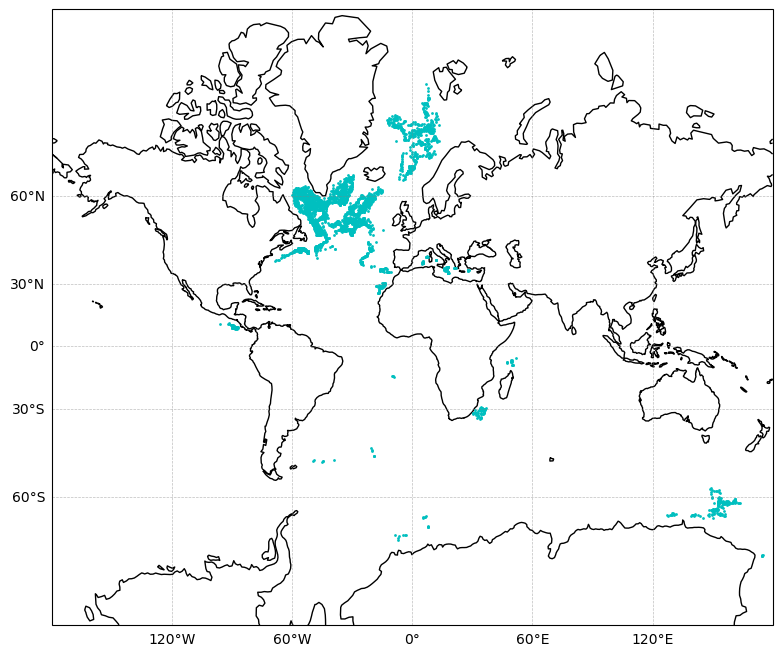

In [11]:
fig=plt.figure(figsize=(12,8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.coastlines()

ax.plot(ds_out['lon_gps'],ds_out['lat_gps'],'.c', markersize=4, markeredgecolor='None', alpha=1, transform=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
ax.set_global()

(array([1.000e+00, 0.000e+00, 6.000e+00, 6.000e+00, 5.300e+01, 4.030e+02,
        7.130e+02, 1.054e+03, 1.019e+03, 3.730e+02]),
 array([0.01560185, 0.07030208, 0.12500231, 0.17970255, 0.23440278,
        0.28910301, 0.34380324, 0.39850347, 0.4532037 , 0.50790394,
        0.56260417]),
 <BarContainer object of 10 artists>)

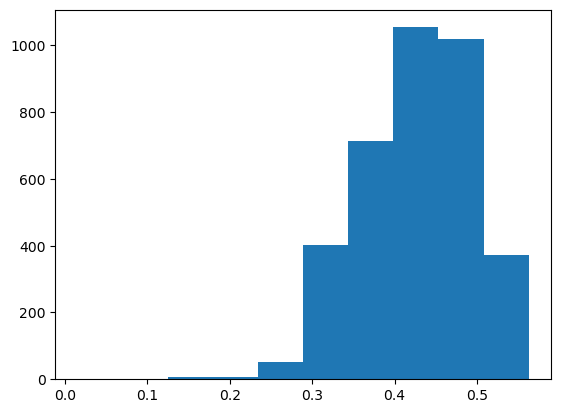

In [12]:
(ds_out['jday_gps']-ds_out['jday_grnd']).plot.hist()

In [13]:
xr.open_dataset('DeepArvorGrounding_ABYSS_2025-02-12.nc')

<xarray.Dataset> Size: 357kB
Dimensions:    (N_GRD: 4965)
Dimensions without coordinates: N_GRD
Data variables:
    lat_gps    (N_GRD) float64 40kB ...
    lon_gps    (N_GRD) float64 40kB ...
    grnd       (N_GRD) float64 40kB ...
    jday_grnd  (N_GRD) datetime64[ns] 40kB ...
    jae_grnd   (N_GRD) datetime64[ns] 40kB ...
    jday_gps   (N_GRD) datetime64[ns] 40kB ...
    jds_grnd   (N_GRD) datetime64[ns] 40kB ...
    wmo        (N_GRD) int64 40kB ...
    cycle      (N_GRD) int64 40kB ...